In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import pickle

In [2]:
import networkx as nx
nx.algorithms.d_separated = nx.algorithms.d_separation.is_d_separator
nx.d_separated = nx.algorithms.d_separation.is_d_separator
from dowhy import CausalModel

In [3]:
DATA_VERSION = '260116'
data = pd.read_pickle(f'../data-definitive/maize-soya-clean-{DATA_VERSION}.pkl')

# DAG dataset

In [4]:
# We will add variables to the data_subset as we will need them
data_base = pd.DataFrame(index=data.index)
data_base['crop_name'] = data.mainharvestcrop
data_base['crop_maize'] = data_base.crop_name == 'maize'
data_base['outcome_prodkgha'] = data.maizeprodkg_ha.fillna(data.soyaprodkg_ha)
data_base['outcome_prodstd'] = (data.maizeprodkg_ha - data.maizeprodkg_ha.mean())/data.maizeprodkg_ha.std()
data_base['outcome_prodstd'] = data_base.outcome_prodstd.fillna(
    (data.soyaprodkg_ha - data.soyaprodkg_ha.mean())/data.soyaprodkg_ha.std()
)
data_base['treat_previousadvice'] = data.previousadvice == 'yes'
data_base['fieldsize_value'] = data.harvestarea_ha
# data[['maizeprodkg_ha']].copy()
# data_subset = data_subset.rename(columns={'maizeprodkg_ha': 'prodkgha'})

In [5]:
data.columns

Index(['FRMRgender', 'previousadvice', 'mainharvestcrop', 'crophistory',
       'crophistory_cropnumber', 'fieldslope', 'landscape', 'soil_texture',
       'est_harvestarea_ha', 'gpsharvestarea_corrected_ha',
       ...
       'estimated_sos', 'estimated_eos', 'estimated_los', 'peak_ndvi_time',
       'peak_ndvi_value', 'sos_ndvi_value', 'eos_ndvi_value', 'ndvi_array_j',
       'elevation', 'innacessibility_index'],
      dtype='object', length=221)

In [6]:
# Soil variables
soil_df = data[[
    'carbon_organic_mean_0_20', 'cation_exchange_capacity_mean_0_20', 'clay_content_mean_0_20', 
    'sand_content_mean_0_20', 'bulk_density_mean_0_20',
]].copy()
soil_df = soil_df.rename(columns={
    'carbon_organic_mean_0_20': 'soilfert_oc', 'cation_exchange_capacity_mean_0_20': 'soilfert_cec',
    'clay_content_mean_0_20': 'soilpp_clay', 'sand_content_mean_0_20': 'soilpp_sand', 
    'bulk_density_mean_0_20': 'soilpp_density', 
})
soilfert_vars = ['soilfert_oc'] # Soil potential fertility
soilpp_vars = ['soilpp_clay', 'soilpp_sand', 'soilpp_density'] # Soil physical properties
soil_df['soil_sandy'] = data.soil_texture == 'sandy'

In [7]:
# Fertilizer variables
fert_df = data[['KGNbasal_ha', 'KGPbasal_ha']].copy()
fert_df.columns = ['fertN_basal', 'fertP_basal']

# Group fertilizer applications by timing and nutriend
for element in ('N', 'P'):
    for i in range(1, 4):
        tmp_df = data[[f'top{i}timing', f'KG{element}top{i}_ha']].copy()
        tmp_df[f'top{i}timing'] = tmp_df[f'top{i}timing'].replace({'tasseling': 'tasseling-silking', 'silking': 'tasseling-silking'})
        tmp_df = pd.pivot_table(
            tmp_df,
            values=f'KG{element}top{i}_ha', columns=f'top{i}timing',
            index='fieldID', fill_value=0, dropna=True
        )
        tmp_df = tmp_df.reindex(data.index)
        tmp_df.columns = tmp_df.columns.str.replace('-', '')
        tmp_df.columns = [f'fert{element}_{i}' for i in tmp_df.columns]
        for col in tmp_df.columns:
            if col in fert_df.columns:
                nan_rows = fert_df[col].isna() & tmp_df[col]
                fert_df[col] = fert_df[col].add(tmp_df[col], fill_value=0)
                fert_df.loc[nan_rows, col] = None
            else:
                fert_df[col] = tmp_df[col]

TIMINGS = [
    'basal', 'emergence', 'kneehigh', '56leaves', '810leaves',
    'tasselingsilking'
]
fert_df_alt = pd.DataFrame(index=fert_df.index)
# Create total N, P and timing dummy variables
for e in ('N', 'P'):
    # min_count=1 ensures that if at least 1 value is non-na, sum is computed and different from NaN
    fert_df_alt[f'fert{e}_total'] = fert_df[[f'fert{e}_{t}' for t in TIMINGS]].sum(axis=1, min_count=1)
    fert_df_alt[f'fert{e}_total'] = fert_df_alt[f'fert{e}_total'].where(lambda x: x<250, np.nan)
    fert_df_alt[[f'fert{e}_{t}' for t in TIMINGS]] = \
        fert_df[[f'fert{e}_{t}' for t in TIMINGS]].div(fert_df_alt[f'fert{e}_total'], axis=0)
    # fert_df_alt = fert_df_alt.dropna()

fert_df = fert_df_alt

fert_df.head()

,fertN_total,fertN_basal,fertN_emergence,fertN_kneehigh,fertN_56leaves,fertN_810leaves,fertN_tasselingsilking,fertP_total,fertP_basal,fertP_emergence,fertP_kneehigh,fertP_56leaves,fertP_810leaves,fertP_tasselingsilking
fieldID,,,,,,,,,,,,,,
nEDtlpqrbz,141.471184,0.000000,0.0,0.000000,0.734694,0.265306,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
y0q886YDHg,71.755375,0.281250,0.0,0.718750,0.000000,0.000000,0.0,22.692637,1.0,0.0,0.0,0.0,0.0,0.0
NfyUaHgMdC,103.558950,0.226891,0.0,0.773109,0.000000,0.000000,0.0,26.420586,1.0,0.0,0.0,0.0,0.0,0.0
qfciDGlEMA,101.407393,0.200000,0.0,0.000000,0.511111,0.288889,0.0,22.805396,1.0,0.0,0.0,0.0,0.0,0.0
1LW4dvza0v,72.672534,0.200000,0.0,0.000000,0.511111,0.288889,0.0,16.343245,1.0,0.0,0.0,0.0,0.0,0.0


In [8]:
np.isclose(fert_df[[f'fertN_{t}' for t in TIMINGS]].sum(axis=1), 1).all(), \
    np.isclose(fert_df[[f'fertP_{t}' for t in TIMINGS]].sum(axis=1), 1).all()

(np.False_, np.False_)

In [9]:
# Map each dev stage to season fraction
stages_map = {
    'planting': (0, 10),
    'emergence': (0, 10),
    '5-6-leaves': (10, 30),
    'knee-high': (20, 40),
    '8-10-leaves': (30, 50),
    'tasseling-silking': (40, 100),
}

In [10]:
# Rain through the different stages
rain_dev_stages_df = pd.DataFrame(index=data.index)
# rain_dev_stages_df['wthstage_rain0to10'] = data['0to10perc_season_prec']
# rain_dev_stages_df['wthstage_rain10to30'] = data[['10to20perc_season_prec', '20to30perc_season_prec']].sum(axis=1)
# rain_dev_stages_df['wthstage_rain20to40'] = data[['20to30perc_season_prec', '30to40perc_season_prec']].sum(axis=1)
# rain_dev_stages_df['wthstage_rain30to50'] = data[['30to40perc_season_prec', '40to50perc_season_prec']].sum(axis=1)
# rain_dev_stages_df['wthstage_rainp40to100'] = data[[f'{i}to{i+10}perc_season_prec' for i in range(40, 100, 10)]].sum(axis=1)
# rain_dev_stages_df['wthstage_rainp0to60'] = data[[f'{i}to{i+10}perc_season_prec' for i in range(0, 60, 10)]].sum(axis=1)

In [11]:
# Seasonal weather
# wth_season_df = data[['0to100perc_season_prec', '0to100perc_season_tmean']].copy()
# wth_season_df.columns = ['wthseason_rain', 'wthseason_tmean']
wth_season_df = data.filter(like='season')

In [12]:
# Single DF for weather
weather_df = pd.concat([rain_dev_stages_df, wth_season_df], axis=1)

In [13]:
# Phenology information
phenology_df = pd.DataFrame(index=data.index)
phenology_df['phenology_losdays'] = data['estimated_los']
# Standardize LOS by crop
tmp_series = data.estimated_los.where(data.mainharvestcrop == 'maize', np.nan)
phenology_df['phenology_losstd'] = (tmp_series - tmp_series.mean())/tmp_series.std()
tmp_series = data.estimated_los.where(data.mainharvestcrop == 'soya', np.nan)
phenology_df['phenology_losstd'] = phenology_df.phenology_losstd.fillna(
    (tmp_series - tmp_series.mean())/tmp_series.std()
)

In [14]:
# Varieties
variety_df = pd.DataFrame(index=data.index)
variety_df['variety_hybrid'] = ~data.maizevariety.isin(['LOCAL_VARIETY', 'CANNOT-REMEMBER-VARIETY', 'UNKNOWN_VARIETY'])
variety_df['variety_hybrid'] = ~variety_df.fillna(data.soyavariety.isin(['local', 'dontknow']))

#
variety_df['variety_recycled'] = data.maizerecycledseed == 'recycled'
variety_df['variety_recycled'] = variety_df.variety_recycled.fillna(
    data.maizerecycledseed.isin(['own', 'otherfarmer', 'relative_friend'])
)

In [15]:
# Crop history
# Define crop history with crop groups based on how they affect soil and managmeent
crop_groups = {
    'legume': ['beans', 'groundnuts', 'pigeonpea', 'soya'],
    'rootandtuber': ['cassava', 'roundpotatoes', 'sweetpotatoes'],
    'oilseed': ['sesame', 'sunflower']
}

def get_group_history(history:str):
    hist = {
        'history_maize': 'maize' in history,
        'history_nocrop': 'no_crop' in history
    }
    for group_name, crops in crop_groups.items():
        hist[f'history_{group_name}'] = any(map(lambda x: x in history, crops))
    return hist

history_df = pd.DataFrame.from_dict(data.crophistory.map(get_group_history).to_dict(), orient='index')

# Add a column for maize and legume at the same time in history. That could indicate maize-legume intercropping
history_df['history_maizelegume'] = history_df.history_maize & history_df.history_legume

In [16]:
# External variables
external_df = data[['elevation', 'innacessibility_index']].copy()
external_df.columns = ['elevation_value', 'accessibility_rai']

In [17]:
# Residue will not be incorporated because it was measured for the end of the season, 
# therefore it could have not affected production. However it could serve as proxy,
# farmers doing it this time are more likely to do it every season
residue_df = pd.get_dummies(
    data.maizeresidues.where(
        data.maizeresidues.fillna(data.soyaresidues).isin(
            ['leave on field', 'burn', 'feed to animals', 'incorporate in the soil']
        ), 
        '0_other'
    ),
    prefix='residue_', drop_first=True, prefix_sep='' 
)
residue_df.columns = [col.replace(' ', '') for col in residue_df.columns]
residue_df['residue_onfield'] =  residue_df[['residue_incorporateinthesoil', 'residue_leaveonfield']].any(axis=1)

# Herbicide
herbicide_df = pd.DataFrame(index=data.index)
herbicide_df['herbicide_post'] = data.maizeherbicides.str.contains('post-emergence').astype(bool)
herbicide_df['herbicide_pre'] = data.maizeherbicides.str.contains('pre-emergence').astype(bool)
herbicide_df['herbicide_any'] = herbicide_df.any(axis=1)


# Manure
manure_df = pd.get_dummies(data.manurefreq, drop_first=False).iloc[:, [0, 2, 3]]
manure_df.columns = ['manure_everyseason', 'manure_oneinmany', 'manure_oneintwo']
manure_df['manure_any'] = manure_df.any(axis=1)
# Leave this to be the only manure variable
manure_df = manure_df[['manure_any']]


# Planting methods
# This could be used as a proxy of farmer knowledge. 
planting_df = pd.DataFrame(index=data.index)
planting_df = planting_df.join(pd.get_dummies(
    data.maizeplantingmethod.fillna(data.soyaplantingmethod), 
    drop_first=True, prefix='planting'
))
planting_df.columns = planting_df.columns.str.replace('-', '')

# Other Management
othermgmt_df = pd.concat([herbicide_df, manure_df, planting_df, residue_df], axis=1)

In [18]:
def calculate_investing_capacity_index(df):
    """
    Calculates an 'Investing Capacity Index' (0-1) for farmers based on survey data.
    
    Dimensions:
    1. Land Score: Percentile rank of harvest area.
    2. Mechanization Score: Max level of tech used in prep/planting (Tractor > Oxen > Hand).
    3. Input Access Score: Use of Fertilizer, Manure, Herbicides, Purchased Seeds, Inoculants.
    
    Args:
    df (pd.DataFrame): The dataframe containing the survey data.
    
    Returns:
    pd.DataFrame: The original dataframe with an added column 'investing_capacity_index'
                  and sub-score columns for analysis.
    """
    data = df.copy()
    
    # --- 1. Land Score (Percentile Rank) ---
    # We use est_harvestarea_ha or harvestarea_ha. 
    # Using rank(pct=True) is robust to outliers and gives a 0-1 uniform distribution.
    q05 = data.harvestarea_ha.quantile(.05)
    q95 = data.harvestarea_ha.quantile(.95)
    data['score_land'] = (data.harvestarea_ha.clip(lower=q05, upper=q95) - q05)/(q95 - q05)
        
    # --- 2. Mechanization Score ---
    # Define mapping: Tractor=1, Animal=0.5, Hand=0
    def get_mech_score(val):
        if pd.isna(val): return 0
        val_str = str(val).lower()
        if 'tractor' in val_str or 'machine' in val_str:
            return 1.0
        elif 'ox' in val_str or 'cattle' in val_str or 'plough' in val_str or 'animal' in val_str:
            return 0.5
        else:
            return 0.0

    # Columns related to land prep and planting for all crops
    mech_cols = [c for c in data.columns if 'fieldprep' in c or 'plantingmethod' in c]
    
    # Calculate max score across all relevant columns for each farmer
    # If they use a tractor anywhere, they get the max score.
    mech_scores = data[mech_cols].map(get_mech_score)
    data['score_mech'] = mech_scores.max(axis=1)

    # --- 3. Input Access Score ---
    input_scores = pd.DataFrame(index=data.index)

    # A. Fertilizer (Binary)
    if 'fertiliser_use' in data.columns:
        # map 'yes'->1, 'little'->0.5, 'no'->0
        input_scores['fert'] = data['fertiliser_use'].map(
            {'yes': 1, 'little': 0.5, 'no': 0, 'dontknow': 0}).fillna(0)
            
    # B. Manure (Binary)
    if 'manure' in data.columns:
        input_scores['manure'] = data['manure'].map(
            {'yes': 1, 'little': 0.5, 'no': 0, 'dontknow': 0}).fillna(0)
    
    # C. Herbicides (Binary: Any use vs no-herbicide)
    # Check all herbicide columns (maize, beans, etc)
    herb_cols = [c for c in data.columns if 'herbicides' in c]
    if herb_cols:
        # If any column has a value that is NOT 'no-herbicide' and not nan, it's a 1.
        def check_herbicide(row):
            for col in herb_cols:
                val = str(row[col]).lower()
                if 'pre-emergence' in val or 'post-emergence' in val:
                    return 1.0
            return 0.0
        input_scores['herb'] = data.apply(check_herbicide, axis=1)

    # D. Seeds (Commercial vs Recycled)
    # Maize: recycled=yes means LOW capital.
    if 'maizerecycledseed' in data.columns:
        # Recycled? Yes=0, No=1
        input_scores['seed_maize'] = data['maizerecycledseed'].map(
            {'no': 1, 'yes': 0, 'little': 0.5}).fillna(0)
            
    # # Beans/Gnuts/Soya: source 'own' vs 'market'
    # # We look for "seedsource" columns
    # seed_source_cols = [c for c in data.columns if 'seedsource' in c]
    # def check_seed_source(val):
    #     if pd.isna(val): return np.nan # Skip if crop not grown
    #     val = str(val).lower()
    #     if 'own' in val or 'neighbor' in val or 'friend' in val:
    #         return 0.0
    #     return 1.0 # Agrodealer, market, government, etc.

    # for col in seed_source_cols:
    #     input_scores[col] = data[col].apply(check_seed_source)

    # Average the input scores (ignoring NaNs for crops not grown)
    data['score_inputs'] = input_scores.mean(axis=1).fillna(0)

    # --- 4. Final Composite Index ---
    data['investing_capacity_index'] = data[['score_land', 'score_mech', 'score_inputs']].mean(axis=1)
    
    # Standardize to 0-1 strictly (optional, usually mean is already 0-1)
    # We round for cleaner output
    data['investing_capacity_index'] = data['investing_capacity_index'].round(3)

    return data[['investing_capacity_index', 'score_land', 'score_mech', 'score_inputs']]

In [19]:
investingcap_df = calculate_investing_capacity_index(data)

In [20]:
# Include a variable for neighborhood treatment assignment
gdf = gpd.read_file('../data-definitive/geo/points.geojson')
gdf = gdf.set_index('fieldID')
gdf['previousadvice'] = gdf.previousadvice == 'yes'

In [21]:
# Convert boolean 'previousadvice' to numeric (0 or 1) for calculation

gdf['previousadvice_numeric'] = gdf['previousadvice'].astype(int)
gdf['neighbor_previousadvice_weighted_avg'] = np.nan
radius_meters = 5000

for index, row in gdf.iterrows():
    current_geometry = row.geometry
    buffer_geom = current_geometry.buffer(radius_meters)
    possible_neighbors_mask = gdf.sindex.query(buffer_geom, predicate='intersects', output_format='dense')
    
    neighbors_df = gdf.iloc[possible_neighbors_mask]
    distances = neighbors_df.geometry.distance(current_geometry)
    valid_neighbors_distances = distances[(distances > 0) & (distances <= radius_meters)]
    
    if not valid_neighbors_distances.empty:
        neighbor_values = neighbors_df.loc[valid_neighbors_distances.index, 'previousadvice_numeric']
        weights = 1 / valid_neighbors_distances
        weighted_avg = (neighbor_values * weights).sum() / weights.sum()
        gdf.loc[index, 'neighbor_previousadvice_weighted_avg'] = weighted_avg

# The temporary 'previousadvice_numeric' column can be dropped if it's no longer needed
gdf = gdf.drop(columns=['previousadvice_numeric'])

In [22]:
neighbors_advice_df = gdf.neighbor_previousadvice_weighted_avg.fillna(0).to_frame(name='neighbor_previousadvice_avg')
neighbors_advice_df = neighbors_advice_df.loc[data_base.index]

In [23]:
# Join all data
data_subset = pd.concat([
    data_base, fert_df, weather_df, soil_df, phenology_df,
    variety_df, history_df, external_df, othermgmt_df, neighbors_advice_df,
    investingcap_df
], axis=1)
data_subset.shape

# Define DAG

The edges were defined after an iterative process with input from the stakeholder(s). The advice is mostly about nutrient management. They don't provide any advice on variety, but they have noticed that hybrid varieties are more prevalent among those that have received the advice. 

The only well known cause for the treatment assignment is the crop history. The extension agent is likely to be biased by their own personal context (e.g. give advice to farmers they know better), and the ease of access to the different fields. Therefore, socio-economic and spatially-variable factors could be an unintentional bias from the extension agent. 

## Edges

In [24]:
edges_list = []

# Define edges to the assignment
edges_list.extend([
    ('fieldHistory', 'previousAdvice'),
    ('accessibilityRAI', 'previousAdvice'),
    ('investmentCap', 'previousAdvice'),
    ('weather', 'previousAdvice'),
    ('soil', 'previousAdvice')
])
# Define edges from treatment
edges_list.extend([
    ('previousAdvice', 'outcome'), 
    ('previousAdvice', 'fertilizerTiming'), 
])
# Edges from treatment spillover component
edges_list.extend([
    # ('neighborsAdvice', 'outcome'), 
    # ('neighborsAdvice', 'fertilizerTiming'), 
])
# Define edges to outcome
edges_list.extend([
    ('fertilizerAmount', 'outcome'),
    ('fertilizerTiming', 'outcome'),
    ('weather', 'outcome'),
    ('soil', 'outcome'),
    ('variety', 'outcome'),
    ('variety', 'phenology'),
    ('fieldHistory', 'outcome'),
    ('phenology', 'outcome'),
    ('otherManagement', 'outcome'),
])
# Define edges defining other management components
edges_list.extend([
    ('investmentCap', 'fertilizerAmount'),
    ('investmentCap', 'variety'),
    ('investmentCap', 'otherManagement'),
    ('accessibilityRAI', 'variety'),
    ('accessibilityRAI', 'fertilizerAmount'),
    ('accessibilityRAI', 'otherManagement'),
    ('fieldHistory', 'fertilizerAmount'),
    ('fieldHistory', 'fertilizerTiming'),
    ('fieldHistory', 'otherManagement'),
    ('soil', 'fertilizerAmount')
    # ('crop', 'fertilizerAmount'),
    # ('crop', 'fertilizerTiming'),
])
# Location related edges
edges_list.extend([
    ('elevation', 'weather'),
    ('elevation', 'soil'),
    ('accessibilityRAI', 'investmentCap'),
])

# Phenology
edges_list.extend([
    ('weather', 'phenology'),
])

## Graph

In [25]:
causal_graph = nx.DiGraph(edges_list)
nodes_list = list(causal_graph.nodes())

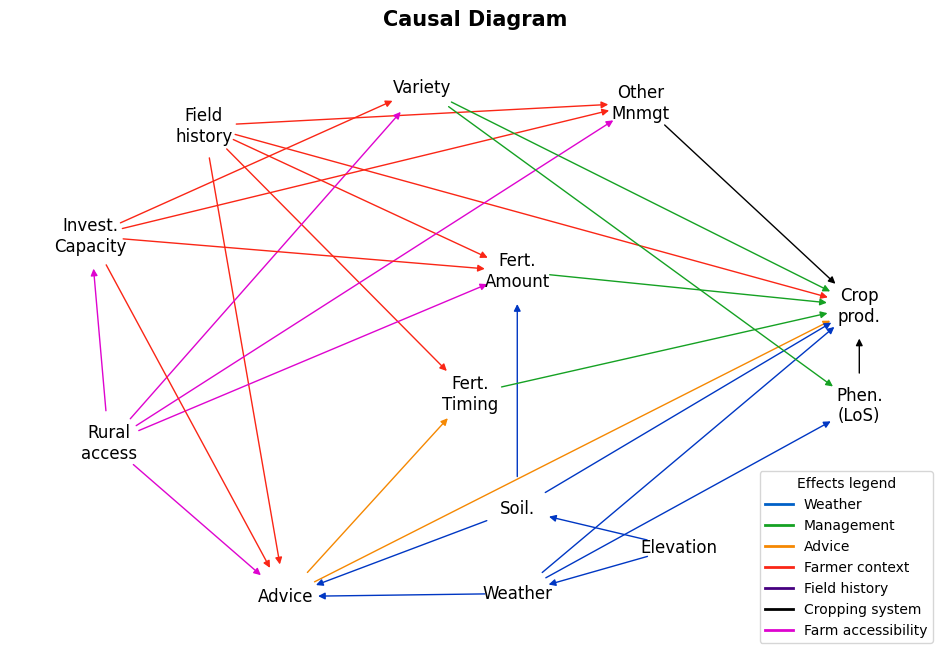

In [26]:
# As some factors are represented by multiple variables (e.g. Variety), 
# we will create a simplified graph that will be the one used when drawing.
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

labels={
    'accessibilityRAI': 'Rural\naccess', 
    # 'crop': 'Crop',
    'fertilizerTiming': 'Fert.\nTiming', 'fertilizerAmount': 'Fert.\nAmount', 
    'fieldHistory': 'Field\nhistory',
    'outcome': 'Crop\nprod.', 'phenology': 'Phen.\n(LoS)', 
    'soil': 'Soil.', 'elevation': 'Elevation',
    'investmentCap': 'Invest.\nCapacity', 'previousAdvice': 'Advice', 'variety': 'Variety',
    'weather': 'Weather', 'otherManagement': "Other\nMnmgt",
    # 'neighborsAdvice': 'Neigh.\nAdvice',
}

edge_colors = []
for cause, effect in causal_graph.edges:
    if cause in ['soil', 'weather', 'elevation']:
        edge_colors.append("#0037C3")
    elif cause in ('fertilizerAmount', 'fertilizerTiming', 'manure', 'variety'):
        edge_colors.append('#15a123')
    elif cause in ('previousAdvice', 'neighborAdvice'):
        edge_colors.append('#f58802')
    elif cause in ('investmentCap', 'fieldHistory'):
        edge_colors.append('#fa2616')
    elif cause in ('accessibilityRAI', 'elevation'):
        edge_colors.append("#de04cf")
    elif cause == 'history':
        edge_colors.append('#460080')
    else:
        edge_colors.append('k')

pos={
    'accessibilityRAI': (-3.8, -0.64), 'crop': (3.5, 2.55), 'cropgrowth': (2.1, 1.15),
    'fertilizerAmount': (0.5, 1.6), 'fertilizerTiming': (0., 0.), 
    'fieldHistory': (-2.8, 3.5), 
    'outcome': (4.1, 1.15), 'phenology': (4.1, -.15), 'elevation': (2.2, -2.),
    'soil': (0.5, -1.5), 'otherManagement': (1.8, 3.8),
    'investmentCap': (-3.99, 2.06), 'previousAdvice': (-1.94, -2.64), 'variety': (-.5, 4.),
    'weather': (0.5, -2.6), 'neighborsAdvice': (-3.99, -2.64),
}

nx.draw_networkx(
    causal_graph, ax=ax, node_size=2200, 
    labels=labels, 
    pos=pos,
    node_shape='o', node_color='#ffffff00', 
    # font_weight={node: 'bold' if node in adj_set_draw else 'normal' for node in labels.keys()},
    edge_color=edge_colors,
    # edgecolors=['k' if node in ('treat', 'outcome') else '#FFFFFF00' for node in causal_graph.nodes]
)
color_labels = [
    # ('#fa2616', 'Technology'), ('#785100', 'Soil'), 
    ('#0060c7', 'Weather'), ('#15a123', 'Management'), 
    ('#f58802', 'Advice'), ('#fa2616', 'Farmer context'), 
    ('#460080', 'Field history'), ('k', 'Cropping system'), 
    ('#de04cf', 'Farm accessibility')
]
ax.legend(handles=[
    mpl.lines.Line2D([], [], color=color, linestyle='-', linewidth=2, label=label)
    for color, label in color_labels
], loc='lower right', title='Effects legend')
ax.set_title('Causal Diagram', fontweight='bold', fontsize=15)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

# Identify backdoor adjustment set

In [27]:
from dowhy.causal_identifier import BackdoorAdjustment
treatment_name = "previousAdvice"
outcome_name = "outcome"
model_advice = CausalModel(
   data=pd.DataFrame(np.ones((1,len(nodes_list))), columns=nodes_list),
   treatment=treatment_name,
   outcome=outcome_name,
   graph="\n".join(nx.generate_gml(causal_graph))
)
identified_estimand_advice = model_advice.identify_effect(
   method_name=BackdoorAdjustment.BACKDOOR_MAX
)
identified_estimand_advice.get_backdoor_variables()

['variety',
 'soil',
 'otherManagement',
 'phenology',
 'weather',
 'fertilizerAmount',
 'investmentCap',
 'elevation',
 'accessibilityRAI',
 'fieldHistory']

In [28]:
treatment_name = "fertilizerAmount"
outcome_name = "outcome"
model_fert = CausalModel(
   data=pd.DataFrame(np.ones((1,len(nodes_list))), columns=nodes_list),
   treatment=treatment_name,
   outcome=outcome_name,
   graph="\n".join(nx.generate_gml(causal_graph)),
   effect_modifiers='fertilizerTiming'
)
identified_estimand_fert = model_fert.identify_effect(
   method_name=BackdoorAdjustment.BACKDOOR_MAX
)
identified_estimand_fert.get_backdoor_variables()

['variety',
 'soil',
 'otherManagement',
 'phenology',
 'weather',
 'fertilizerTiming',
 'investmentCap',
 'elevation',
 'accessibilityRAI',
 'previousAdvice',
 'fieldHistory']

In [29]:
from dowhy.causal_identifier import AutoIdentifier, EstimandType
treatment_name = "previousAdvice"
identified_estimand_advice = AutoIdentifier(
    estimand_type=EstimandType.NONPARAMETRIC_ATE,
    backdoor_adjustment=BackdoorAdjustment.BACKDOOR_MIN_EFFICIENT,
)
identified_estimand_advice = identified_estimand_advice.identify_effect(
    graph=causal_graph,
    action_nodes=treatment_name,
    outcome_nodes=outcome_name,
    observed_nodes=nodes_list,
    conditional_node_names=['soil']
)
identified_estimand_advice.get_backdoor_variables()

['weather',
 'variety',
 'soil',
 'otherManagement',
 'fertilizerAmount',
 'fieldHistory']

In [30]:
treatment_name = "fertilizerAmount"
identified_estimand_fert = AutoIdentifier(
    estimand_type=EstimandType.NONPARAMETRIC_ATE,
    backdoor_adjustment=BackdoorAdjustment.BACKDOOR_MIN_EFFICIENT,
)
identified_estimand_fert = identified_estimand_fert.identify_effect(
    graph=causal_graph,
    action_nodes=treatment_name,
    outcome_nodes=outcome_name,
    observed_nodes=nodes_list,
    conditional_node_names=['fertilizerTiming']
)
identified_estimand_fert.get_backdoor_variables()

['variety',
 'soil',
 'otherManagement',
 'weather',
 'fertilizerTiming',
 'previousAdvice',
 'fieldHistory']

In [32]:
data_subset.to_pickle(f'../data-definitive/data-dag-{DATA_VERSION}.pkl')